In [4]:
import numpy as np
import matplotlib.pyplot as plt

class k_means():
    def __init__(self, k=2, max_iters=100):
        self.k = k
        self.max_iters = max_iters
        self.centroids = None
        self.inertia = None
        
    def fit(self, X):
        n_samples, n_features = X.shape
        # Initialize centroids randomly from the data points
        self.centroids = X[np.random.choice(n_samples, self.k, replace=False)]
        
        for iter in range(self.max_iters):
            # Assign clusters
            distances = np.linalg.norm(X[:, np.newaxis] - self.centroids, axis=2)
            self.inertia = np.sum(np.min(distances, axis=1))
            closest_centroids = np.argmin(distances, axis=1)
            
            # Update centroids
            old_centroids = self.centroids.copy()
            for j in range(self.k):
                if np.any(closest_centroids == j):
                    self.centroids[j] = X[closest_centroids == j].mean(axis=0)
            
            # Check for convergence (if centroids do not change)
            if iter > 0 and np.all(self.centroids == old_centroids):
                print("Convergence reached after", iter + 1, "iterations.")
                break
            
    def predict(self, X):
        distances = np.linalg.norm(X[:, np.newaxis] - self.centroids, axis=2)
        closest_centroids = np.argmin(distances, axis=1)
        return closest_centroids

In [7]:
class EM():
    def __init__(self, k=2, max_iters=100):
        self.k = k
        self.max_iters = max_iters
        self.means = None
        self.covariances = None
        self.weights = None
        self.log_likelihood = None
        
    def fit(self, X):
        n_samples, n_features = X.shape
        # Initialize means randomly from the data points
        self.means = X[np.random.choice(n_samples, self.k, replace=False)]
        self.covariances = np.array([np.eye(n_features) for _ in range(self.k)])
        self.weights = np.ones(self.k) / self.k
        
        for iter in range(self.max_iters):
            # E-step: Compute responsibilities
            responsibilities = np.zeros((n_samples, self.k))
            for j in range(self.k):
                diff = X - self.means[j]
                inv_cov = np.linalg.inv(self.covariances[j])
                exponent = -0.5 * np.sum(diff @ inv_cov * diff, axis=1)
                responsibilities[:, j] = self.weights[j] * np.exp(exponent) / np.sqrt(np.linalg.det(self.covariances[j]))
            responsibilities /= responsibilities.sum(axis=1, keepdims=True)
            
            # M-step: Update parameters
            Nk = responsibilities.sum(axis=0)
            for j in range(self.k):
                self.means[j] = (responsibilities[:, j][:, np.newaxis] * X).sum(axis=0) / Nk[j]
                diff = X - self.means[j]
                self.covariances[j] = (responsibilities[:, j][:, np.newaxis] * diff).T @ diff / Nk[j]
                self.weights[j] = Nk[j] / n_samples
            
            # Compute log-likelihood
            log_likelihood_new = np.sum(np.log(responsibilities.sum(axis=1)))
            if iter > 0 and abs(log_likelihood_new - self.log_likelihood) < 1e-6:
                print("Convergence reached after", iter + 1, "iterations.")
                break
            self.log_likelihood = log_likelihood_new
            
    def predict(self, X):
        responsibilities = np.zeros((X.shape[0], self.k))
        for j in range(self.k):
            diff = X - self.means[j]
            inv_cov = np.linalg.inv(self.covariances[j])
            exponent = -0.5 * np.sum(diff @ inv_cov * diff, axis=1)
            responsibilities[:, j] = self.weights[j] * np.exp(exponent) / np.sqrt(np.linalg.det(self.covariances[j]))
        responsibilities /= responsibilities.sum(axis=1, keepdims=True)
        return np.argmax(responsibilities, axis=1)

Convergence reached after 5 iterations.
Convergence reached after 4 iterations.
Convergence reached after 8 iterations.
Convergence reached after 4 iterations.
Convergence reached after 4 iterations.
Convergence reached after 5 iterations.
Convergence reached after 4 iterations.
Convergence reached after 3 iterations.
Convergence reached after 3 iterations.
Convergence reached after 2 iterations.
Convergence reached after 2 iterations.
Convergence reached after 3 iterations.
Convergence reached after 3 iterations.
Convergence reached after 3 iterations.
Convergence reached after 3 iterations.
Convergence reached after 4 iterations.
Convergence reached after 2 iterations.
Convergence reached after 3 iterations.
Convergence reached after 2 iterations.
Convergence reached after 2 iterations.
Convergence reached after 2 iterations.


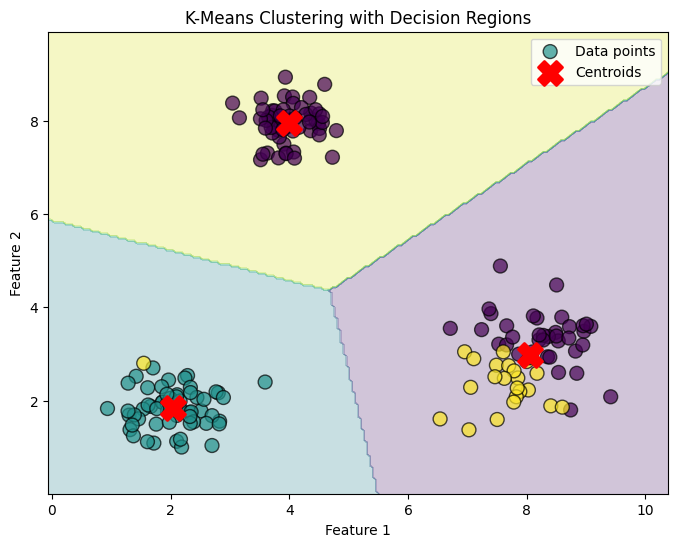

In [ ]:
# Fit model
centers = np.array([
    [2, 2],
    [8, 3],
    [4, 8]
])

X = np.vstack([
    np.random.randn(60, 2) * 0.5 + centers[0],
    np.random.randn(60, 2) * 0.6 + centers[1],
    np.random.randn(60, 2) * 0.4 + centers[2],
])

best_kmeans = None
best_inertia = float('inf')

for _ in range(20):
    km = k_means(k=3)
    km.fit(X)
    if km.inertia < best_inertia:
        best_inertia = km.inertia
        best_kmeans = km

kmeans = best_kmeans

predictions = kmeans.predict(X)

em = EM(k=3)
em.fit(X)
predictions = em.predict(X)

# ----- CREATE GRID FOR DECISION REGIONS -----
h = 0.05  # grid resolution

x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.arange(x_min, x_max, h),
    np.arange(y_min, y_max, h)
)

# Predict cluster for each grid point
grid_points = np.c_[xx.ravel(), yy.ravel()]
Z = kmeans.predict(grid_points)
Z = Z.reshape(xx.shape)

# ----- PLOT -----
plt.figure(figsize=(8, 6))

# Cluster regions
plt.contourf(xx, yy, Z, cmap='viridis', alpha=0.25)

# Data points
plt.scatter(
    X[:, 0], X[:, 1],
    c=predictions,
    cmap='viridis',
    s=100,
    edgecolor='k',
    alpha=0.7,
    label='Data points'
)

# Centroids
plt.scatter(
    kmeans.centroids[:, 0],
    kmeans.centroids[:, 1],
    c='red',
    marker='X',
    s=300,
    linewidths=2,
    label='Centroids'
)

plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('K-Means Clustering with Decision Regions')
plt.legend()
plt.show()
